This project reproduces an econometric analysis of dynamic relationships between three major cryptocurrencies: Bitcoin (BTC), Ethereum (ETH), and Solana (SOL).  
The original version was prepared in R and focused on daily price data from Yahoo Finance, transformed into log returns and analyzed with a Vector Autoregression (VAR) model. The broader goal of the project is to examine short-term interdependence between these cryptocurrencies and to assess whether the VAR model provides useful predictive information.



## Section 1. Data collection and preparation

The purpose of this section is to reproduce the first stage of the original R workflow in Python.  
We download daily price data for BTC, ETH and SOL from Yahoo Finance, align the series to a common time index, remove missing values and transform prices into daily log returns. This step is necessary because return series are more appropriate for time-series modelling than raw price levels.

### R to Python translation for Section 1

The original R code used:
- `quantmod` for downloading data from Yahoo Finance,
- `xts` for handling time-indexed financial series.

In Python, the corresponding workflow is implemented with:
- `yfinance` for downloading market data,
- `pandas` for aligning time series and handling missing values,
- `numpy` for computing daily log returns,
- `matplotlib` for plotting the transformed series.

In [10]:
%pip install yfinance arch statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

In [12]:
# Download daily price data

tickers = ["BTC-USD", "ETH-USD", "SOL-USD"]
start_date = "2017-01-01"
end_date = "2025-09-06"

prices = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)["Close"]
prices.columns = ["BTC", "ETH", "SOL"]

[*********************100%***********************]  3 of 3 completed


### Align the series and compute daily log returns

Because the three cryptocurrencies have different starting dates, the series must be aligned to a common sample.
After that, prices are transformed into daily log returns and missing values are removed.

In [13]:
returns = np.log(prices / prices.shift(1)).dropna()

print("Common sample range:", returns.index.min().date(), "->", returns.index.max().date())
returns.head()

Common sample range: 2020-04-11 -> 2025-09-05


,BTC,ETH,SOL
Date,,,
2020-04-11,-0.000934,-0.001241,-0.202363
2020-04-12,0.016198,0.018327,0.127559
2020-04-13,-0.018248,-0.030642,-0.126256
2020-04-14,-0.000381,0.008391,-0.161358
2020-04-15,-0.029713,-0.027726,-0.023346


### Plot daily log returns

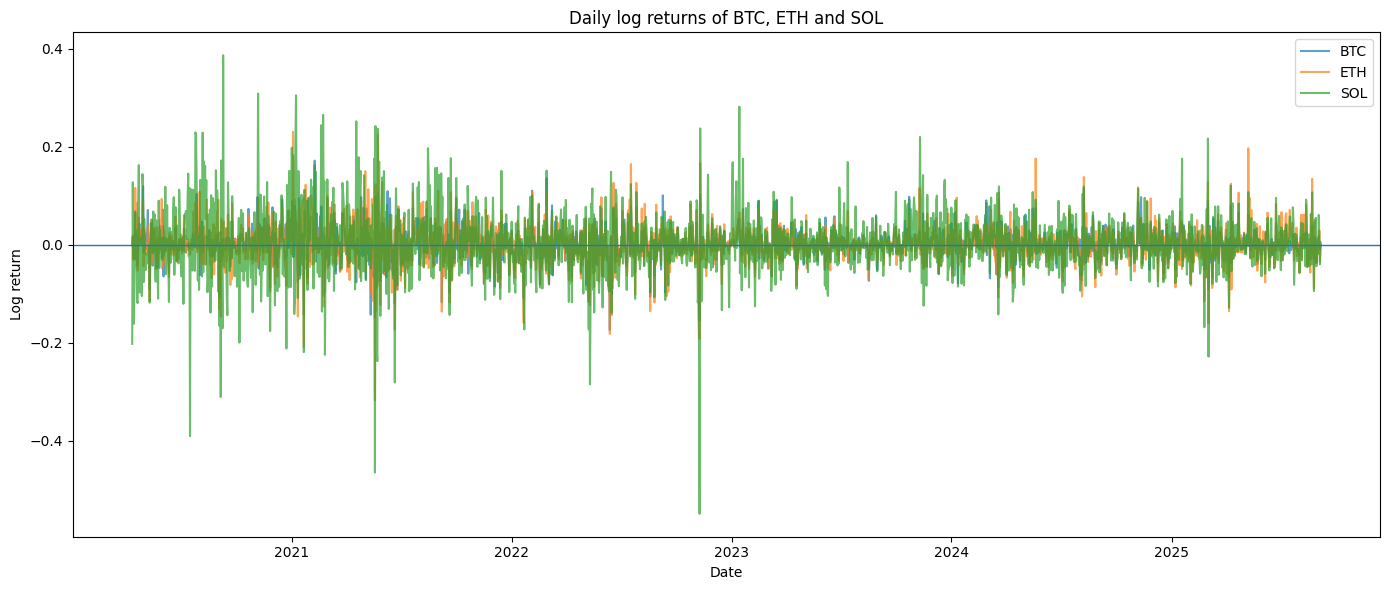

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(returns.index, returns["BTC"], label="BTC", alpha=0.7)
plt.plot(returns.index, returns["ETH"], label="ETH", alpha=0.7)
plt.plot(returns.index, returns["SOL"], label="SOL", alpha=0.7)

plt.axhline(0, linewidth=1)
plt.title("Daily log returns of BTC, ETH and SOL")
plt.xlabel("Date")
plt.ylabel("Log return")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation

The daily log-return series fluctuate around zero, which is typical for financial returns.
Periods of increased volatility are clearly visible, especially for SOL, which shows the largest spikes.
This confirms that return series capture short-term market dynamics better than raw price levels.

## Section 2. Stationarity tests

In this section, we test whether the daily log returns of BTC, ETH and SOL are stationary.

Following the original R workflow, we use:
- the Augmented Dickey–Fuller (ADF) test,
- the Phillips–Perron (PP) test,
- the KPSS test.

For ADF and PP, the null hypothesis is the presence of a unit root.
For KPSS, the null hypothesis is stationarity.

### R to Python translation for Section 2

In the original R version, stationarity tests were implemented with the `urca` package:
- `ur.df()` for ADF,
- `ur.pp()` for PP,
- `ur.kpss()` for KPSS.

In Python, we use:
- `statsmodels.tsa.stattools.adfuller` for ADF,
- `arch.unitroot.PhillipsPerron` for PP,
- `statsmodels.tsa.stattools.kpss` for KPSS.

In [15]:
def adf_test(series):
    result = adfuller(series, regression="c", autolag="AIC")
    return result[0], result[1]

def pp_test(series):
    result = PhillipsPerron(series)
    return result.stat, result.pvalue

def kpss_test(series):
    result = kpss(series, regression="c", nlags="auto")
    return result[0], result[1]

### Run the tests for BTC, ETH and SOL

In [16]:
results = []

for col in ["BTC", "ETH", "SOL"]:
    adf_stat, adf_p = adf_test(returns[col])
    pp_stat, pp_p = pp_test(returns[col])
    kpss_stat, kpss_p = kpss_test(returns[col])

    results.append([col, "ADF", adf_stat, adf_p])
    results.append([col, "PP", pp_stat, pp_p])
    results.append([col, "KPSS", kpss_stat, kpss_p])

results_df = pd.DataFrame(results, columns=["Variable", "Test", "Statistic", "p-value"])
results_df

C:\Users\Komputer\AppData\Local\Temp\ipykernel_10680\130476825.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression="c", nlags="auto")
C:\Users\Komputer\AppData\Local\Temp\ipykernel_10680\130476825.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression="c", nlags="auto")


,Variable,Test,Statistic,p-value
0,BTC,ADF,-14.042568,3.283563e-26
1,BTC,PP,-46.034340,0.000000e+00
2,BTC,KPSS,0.212650,1.000000e-01
3,ETH,ADF,-11.698970,1.585517e-21
4,ETH,PP,-46.346487,0.000000e+00
5,ETH,KPSS,0.359890,9.444406e-02
6,SOL,ADF,-20.915606,0.000000e+00
7,SOL,PP,-47.044366,0.000000e+00
8,SOL,KPSS,0.282006,1.000000e-01


In [17]:
summary_rows = []

for col in ["BTC", "ETH", "SOL"]:
    sub = results_df[results_df["Variable"] == col]

    adf_p = sub[sub["Test"] == "ADF"]["p-value"].values[0]
    pp_p = sub[sub["Test"] == "PP"]["p-value"].values[0]
    kpss_p = sub[sub["Test"] == "KPSS"]["p-value"].values[0]

    conclusion = "Stationary" if (adf_p < 0.05 and pp_p < 0.05 and kpss_p > 0.05) else "Needs review"
    summary_rows.append([col, adf_p, pp_p, kpss_p, conclusion])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Variable", "ADF p-value", "PP p-value", "KPSS p-value", "Conclusion"]
)

summary_df

,Variable,ADF p-value,PP p-value,KPSS p-value,Conclusion
0,BTC,3.283563e-26,0.0,0.100000,Stationary
1,ETH,1.585517e-21,0.0,0.094444,Stationary
2,SOL,0.000000e+00,0.0,0.100000,Stationary


### Interpretation of stationarity test results

The results are consistent across all three cryptocurrencies.

- In the **ADF test**, the null hypothesis of a unit root is rejected for BTC, ETH and SOL.
- In the **PP test**, the null hypothesis of a unit root is also rejected for all three series.
- In the **KPSS test**, the null hypothesis of stationarity is not rejected.

Therefore, the daily log-return series can be treated as **stationary**.
This means they are suitable for the next stage of the analysis, namely estimation of the VAR model.

The KPSS warning shown above does not affect the interpretation. It only indicates that the true p-value is larger than the value reported by the lookup table.